### 1. Load Data & Imports

In [1]:
import pandas as pd  # DataFrame library
import numpy as np  # numeric arrays, used later for RNG/argmax

df = pd.read_csv("customer_segmentation_100k.csv")  # load raw customer data (100k rows)
df.head()  # peek at first 5 rows to sanity-check columns/types

,CustomerID,Age,Gender,AnnualIncome,Education,Occupation,City,TenureMonths,MembershipTier,PreferredChannel,...,WebsiteVisitsPerMonth,AppUsageHoursPerMonth,DiscountUsesPerYear,Returns,LastPurchaseDays,SatisfactionScore,SupportTickets,EmailOpenRatePct,CartAbandonmentRatePct,Churned
0,C000001,56,Female,68248,Bachelor,Sales,Kochi,51,NaN,Store,...,15,5.8,7,4,60,10.0,0,61.6,48.0,1
1,C000002,69,Female,41354,Bachelor,Teacher,Madurai,5,Platinum,Website,...,14,22.1,7,0,10,8.1,2,62.9,49.9,0
2,C000003,46,Male,62086,Diploma,IT,Bengaluru,89,Gold,Website,...,16,14.9,3,0,127,8.1,0,47.5,13.6,1
3,C000004,32,Male,34670,Diploma,Student,Madurai,79,Silver,Store,...,18,23.4,3,0,137,6.7,1,75.9,23.4,1
4,C000005,60,Male,25635,Master,Student,Kochi,42,Gold,Mobile App,...,21,15.1,8,2,42,9.9,2,40.6,68.7,0


### 2. Inspect Data Types & Structure

In [2]:
df.info()  # column dtypes, non-null counts, memory usage

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CustomerID                 100000 non-null  str    
 1   Age                        100000 non-null  int64  
 2   Gender                     100000 non-null  str    
 3   AnnualIncome               100000 non-null  int64  
 4   Education                  100000 non-null  str    
 5   Occupation                 100000 non-null  str    
 6   City                       100000 non-null  str    
 7   TenureMonths               100000 non-null  int64  
 8   MembershipTier             60053 non-null   str    
 9   PreferredChannel           100000 non-null  str    
 10  TotalPurchases             100000 non-null  int64  
 11  TotalSpend                 100000 non-null  float64
 12  AvgOrderValue              100000 non-null  float64
 13  PurchaseFrequencyPerMonth  100000 non-nul

### 3. Check for Missing Values

In [3]:
df.isna().sum()  # NaN count per column (e.g. MembershipTier looked NaN in row 0)
# NOTE: counts are only printed here -- nothing below actually drops/fills them

CustomerID                       0
Age                              0
Gender                           0
AnnualIncome                     0
Education                        0
Occupation                       0
City                             0
TenureMonths                     0
MembershipTier               39947
PreferredChannel                 0
TotalPurchases                   0
TotalSpend                       0
AvgOrderValue                    0
PurchaseFrequencyPerMonth        0
WebsiteVisitsPerMonth            0
AppUsageHoursPerMonth            0
DiscountUsesPerYear              0
Returns                          0
LastPurchaseDays                 0
SatisfactionScore                0
SupportTickets                   0
EmailOpenRatePct                 0
CartAbandonmentRatePct           0
Churned                          0
dtype: int64

### 4. Check for Duplicate Rows

In [4]:
df.duplicated().sum()  # count of exact duplicate rows
# NOTE: like the NaN check above, duplicates are counted but never removed

np.int64(0)

### 5. Re-check Data Info (redundant)

In [5]:
df.info()  # identical to cell 2 -- df hasn't changed, so this adds no new information

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CustomerID                 100000 non-null  str    
 1   Age                        100000 non-null  int64  
 2   Gender                     100000 non-null  str    
 3   AnnualIncome               100000 non-null  int64  
 4   Education                  100000 non-null  str    
 5   Occupation                 100000 non-null  str    
 6   City                       100000 non-null  str    
 7   TenureMonths               100000 non-null  int64  
 8   MembershipTier             60053 non-null   str    
 9   PreferredChannel           100000 non-null  str    
 10  TotalPurchases             100000 non-null  int64  
 11  TotalSpend                 100000 non-null  float64
 12  AvgOrderValue              100000 non-null  float64
 13  PurchaseFrequencyPerMonth  100000 non-nul

### 6. Select Features & Scale (StandardScaler)

In [6]:
from sklearn.preprocessing import StandardScaler

# the 8 numeric columns that will actually feed the clustering model
features = ['AnnualIncome','TotalSpend','PurchaseFrequencyPerMonth','WebsiteVisitsPerMonth',
'AppUsageHoursPerMonth','DiscountUsesPerYear','Returns','LastPurchaseDays']

scale = StandardScaler()  # zero-mean, unit-variance scaler (this exact object gets pickled later)
X_scaled = scale.fit_transform(df[features])  # fit on all 100k rows and transform -> numpy array

X_scaled.mean()  # sanity check: should be ~0 for every column

np.float64(-3.979039320256561e-17)

### 7. Verify Scaling (Std Dev Check)

In [7]:
X_scaled.std()  # sanity check: should be ~1 for every column

np.float64(1.0)

### 8. Elbow/Silhouette Method (section marker)

In [8]:
# Test different k values
# -- this cell is just a comment/header, no code runs here

### 9. Sweep K = 2..8: Inertia + Silhouette Score

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []            # within-cluster sum of squares per k
silhouette_scores = []  # silhouette score per k (higher = better separated clusters)

# Sample for faster silhouette calculation
sample_size = 3000
rng = np.random.RandomState(42)  # fixed seed for reproducible sampling
sample_indices = rng.choice(
    len(X_scaled),
    sample_size,
    replace=False
)  # 3000 random row indices out of 100k, used only for scoring (not for fitting)

X_sample = X_scaled[sample_indices]  # scaled features for just the sampled rows

k_values = range(2, 9)  # try k = 2,3,...,8

for k in k_values:
    print(f"Testing K={k}...")

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=5
    )  # NOTE: a fresh KMeans is created and fit for EVERY k -- expensive on 100k rows x 7 values of k

    # Train on all 100K customers
    labels = model.fit_predict(X_scaled)  # cluster assignment for every customer at this k

    # Inertia
    inertia.append(model.inertia_)  # store for a (currently unplotted) elbow curve

    # Silhouette on sample
    sample_labels = labels[sample_indices]  # pull out labels for just the 3000 sampled rows

    score = silhouette_score(
        X_sample,
        sample_labels
    )  # silhouette computed only on the sample, for speed

    silhouette_scores.append(score)

    print(
        f"K={k} | "
        f"Inertia={model.inertia_:.2f} | "
        f"Silhouette={score:.4f}"
    )

best_k = list(k_values)[
    np.argmax(silhouette_scores)
]  # k with the single highest silhouette score wins -- could be anywhere from 2 to 8

print("\nBest K:", best_k)

Testing K=2...
K=2 | Inertia=692303.55 | Silhouette=0.1945
Testing K=3...
K=3 | Inertia=635174.40 | Silhouette=0.1074
Testing K=4...
K=4 | Inertia=591886.20 | Silhouette=0.1036
Testing K=5...
K=5 | Inertia=553257.11 | Silhouette=0.1060
Testing K=6...
K=6 | Inertia=523373.28 | Silhouette=0.1021
Testing K=7...
K=7 | Inertia=498594.41 | Silhouette=0.1028
Testing K=8...
K=8 | Inertia=477714.66 | Silhouette=0.1010

Best K: 2


### 10. Fit Final KMeans Model with best_k

In [10]:
# Create final K-Means model
kmeans = KMeans(
    n_clusters=best_k,   # whatever won the silhouette sweep above -- NOT guaranteed to be 2
    random_state=42,
    n_init=10            # more restarts than the sweep (n_init=5) for a more stable final fit
)

# Assign every customer to a cluster
df["Cluster"] = kmeans.fit_predict(X_scaled)  # adds a new integer column 0..best_k-1

print("Clustering completed!")
print("\nCluster counts:")
print(df["Cluster"].value_counts().sort_index())  # how many customers landed in each cluster

Clustering completed!

Cluster counts:
Cluster
0    79094
1    20906
Name: count, dtype: int64


### 11. View Clustered DataFrame

In [11]:
df  # display full dataframe now that it has a Cluster column

,CustomerID,Age,Gender,AnnualIncome,Education,Occupation,City,TenureMonths,MembershipTier,PreferredChannel,...,AppUsageHoursPerMonth,DiscountUsesPerYear,Returns,LastPurchaseDays,SatisfactionScore,SupportTickets,EmailOpenRatePct,CartAbandonmentRatePct,Churned,Cluster
0,C000001,56,Female,68248,Bachelor,Sales,Kochi,51,NaN,Store,...,5.8,7,4,60,10.0,0,61.6,48.0,1,0
1,C000002,69,Female,41354,Bachelor,Teacher,Madurai,5,Platinum,Website,...,22.1,7,0,10,8.1,2,62.9,49.9,0,0
2,C000003,46,Male,62086,Diploma,IT,Bengaluru,89,Gold,Website,...,14.9,3,0,127,8.1,0,47.5,13.6,1,0
3,C000004,32,Male,34670,Diploma,Student,Madurai,79,Silver,Store,...,23.4,3,0,137,6.7,1,75.9,23.4,1,0
4,C000005,60,Male,25635,Master,Student,Kochi,42,Gold,Mobile App,...,15.1,8,2,42,9.9,2,40.6,68.7,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,C099996,30,Male,88159,Diploma,Finance,Bengaluru,84,Gold,Marketplace,...,13.6,5,2,62,5.5,6,67.3,33.4,1,1
99996,C099997,53,Male,115206,Bachelor,Engineer,Mumbai,9,NaN,Store,...,1.5,6,3,32,6.1,0,31.9,29.2,1,1
99997,C099998,33,Female,32492,Bachelor,Healthcare,Hyderabad,63,Silver,Store,...,6.2,4,2,11,8.1,1,42.4,3.0,0,0
99998,C099999,57,Female,35181,Master,IT,Chennai,93,Silver,Store,...,7.1,8,0,10,7.5,1,59.1,14.1,1,0


### 12. Cluster Summary Stats (first pass)

In [12]:
cluster_summary = df.groupby("Cluster")[
    [
        "Age",
        "AnnualIncome",
        "TotalSpend",
        "TotalPurchases",         # note: not part of `features` used for scaling/clustering
        "PurchaseFrequencyPerMonth",
        "WebsiteVisitsPerMonth",
        "LastPurchaseDays",
        "SatisfactionScore",
        "Churned"
    ]
].mean().round(2)  # per-cluster average of each business metric

cluster_summary

,Age,AnnualIncome,TotalSpend,TotalPurchases,PurchaseFrequencyPerMonth,WebsiteVisitsPerMonth,LastPurchaseDays,SatisfactionScore,Churned
Cluster,,,,,,,,,
0,43.46,49725.16,55417.99,272.22,4.51,15.00,49.57,7.47,0.54
1,43.64,117853.91,168770.40,272.46,4.50,14.98,49.84,7.47,0.54


### 13. Visualize Clusters (Income vs Spend)

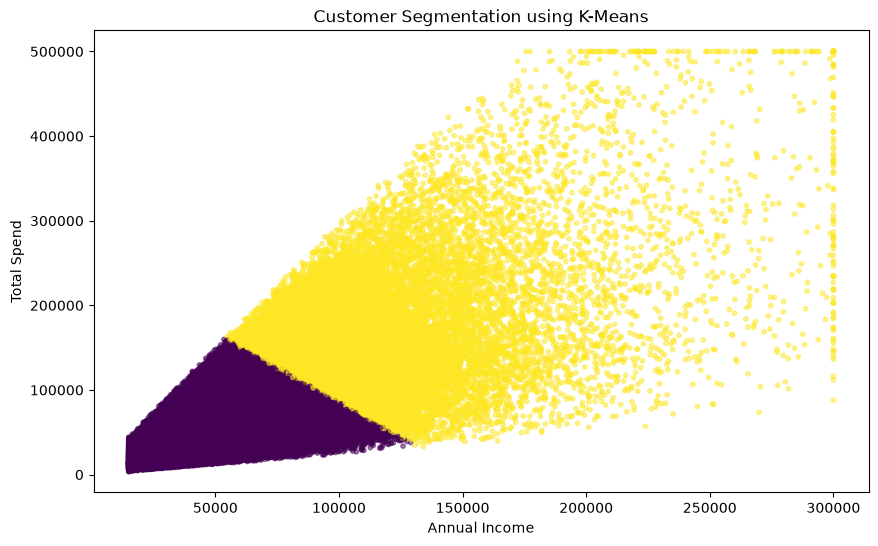

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["AnnualIncome"],
    df["TotalSpend"],
    c=df["Cluster"],   # color points by cluster id
    s=10,
    alpha=0.5
)  # 2D projection using only 2 of the 8 clustering features -- other dimensions aren't shown

plt.xlabel("Annual Income")
plt.ylabel("Total Spend")
plt.title("Customer Segmentation using K-Means")

plt.show()

### 14. Cluster Summary Stats (duplicate of #12)

In [14]:
# Display cluster averages
cluster_summary = df.groupby("Cluster")[
    [
        "Age",
        "AnnualIncome",
        "TotalSpend",
        "TotalPurchases",
        "PurchaseFrequencyPerMonth",
        "WebsiteVisitsPerMonth",
        "LastPurchaseDays",
        "SatisfactionScore",
        "Churned"
    ]
].mean().round(2)  # identical computation to cell 11 -- copy/paste leftover

cluster_summary

,Age,AnnualIncome,TotalSpend,TotalPurchases,PurchaseFrequencyPerMonth,WebsiteVisitsPerMonth,LastPurchaseDays,SatisfactionScore,Churned
Cluster,,,,,,,,,
0,43.46,49725.16,55417.99,272.22,4.51,15.00,49.57,7.47,0.54
1,43.64,117853.91,168770.40,272.46,4.50,14.98,49.84,7.47,0.54


### 15. Per-Cluster Detailed Print Report

In [15]:
for cluster in sorted(df["Cluster"].unique()):  # loop over every cluster id that actually exists

    data = df[df["Cluster"] == cluster]  # rows belonging to this cluster

    print("\n" + "=" * 50)
    print("CLUSTER:", cluster)
    print("Customers:", len(data))

    print("Average Income:",
          round(data["AnnualIncome"].mean(), 2))

    print("Average Spend:",
          round(data["TotalSpend"].mean(), 2))

    print("Average Purchases:",
          round(data["TotalPurchases"].mean(), 2))

    print("Purchase Frequency:",
          round(data["PurchaseFrequencyPerMonth"].mean(), 2))

    print("Days Since Last Purchase:",
          round(data["LastPurchaseDays"].mean(), 2))

    print("Satisfaction:",
          round(data["SatisfactionScore"].mean(), 2))

    print("Churn Rate:",
          round(data["Churned"].mean() * 100, 2), "%")


CLUSTER: 0
Customers: 79094
Average Income: 49725.16
Average Spend: 55417.99
Average Purchases: 272.22
Purchase Frequency: 4.51
Days Since Last Purchase: 49.57
Satisfaction: 7.47
Churn Rate: 53.86 %

CLUSTER: 1
Customers: 20906
Average Income: 117853.91
Average Spend: 168770.4
Average Purchases: 272.46
Purchase Frequency: 4.5
Days Since Last Purchase: 49.84
Satisfaction: 7.47
Churn Rate: 54.0 %


### 16. Build Aggregated Segment Profile Table

In [16]:
segment_profile = df.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_Income=("AnnualIncome", "mean"),
    Avg_Spend=("TotalSpend", "mean"),
    Avg_Purchases=("TotalPurchases", "mean"),
    Purchase_Frequency=("PurchaseFrequencyPerMonth", "mean"),
    Website_Visits=("WebsiteVisitsPerMonth", "mean"),
    Days_Since_Purchase=("LastPurchaseDays", "mean"),
    Satisfaction=("SatisfactionScore", "mean"),
    Churn_Rate=("Churned", "mean")   # mean of a 0/1 column = churn fraction, still 0-1 here
).round(2)

segment_profile["Churn_Rate"] *= 100  # convert fraction to a percentage in place

segment_profile

,Customers,Avg_Age,Avg_Income,Avg_Spend,Avg_Purchases,Purchase_Frequency,Website_Visits,Days_Since_Purchase,Satisfaction,Churn_Rate
Cluster,,,,,,,,,,
0,79094,43.46,49725.16,55417.99,272.22,4.51,15.00,49.57,7.47,54.0
1,20906,43.64,117853.91,168770.40,272.46,4.50,14.98,49.84,7.47,54.0


### 17. Sort Segments by Average Spend

In [17]:
segment_profile = segment_profile.sort_values(
    "Avg_Spend",
    ascending=False   # highest-spending cluster first
)

segment_profile

,Customers,Avg_Age,Avg_Income,Avg_Spend,Avg_Purchases,Purchase_Frequency,Website_Visits,Days_Since_Purchase,Satisfaction,Churn_Rate
Cluster,,,,,,,,,,
1,20906,43.64,117853.91,168770.40,272.46,4.50,14.98,49.84,7.47,54.0
0,79094,43.46,49725.16,55417.99,272.22,4.51,15.00,49.57,7.47,54.0


### 18. Identify At-Risk (High Churn) Segments

In [18]:
at_risk = segment_profile.sort_values(
    "Churn_Rate",
    ascending=False   # highest churn cluster first
)

at_risk[[
    "Customers",
    "Avg_Spend",
    "Purchase_Frequency",
    "Days_Since_Purchase",
    "Churn_Rate"
]]  # narrower view focused on churn-relevant columns

,Customers,Avg_Spend,Purchase_Frequency,Days_Since_Purchase,Churn_Rate
Cluster,,,,,
1,20906,168770.40,4.50,49.84,54.0
0,79094,55417.99,4.51,49.57,54.0


### 19. Map Cluster IDs to Human-Readable Segment Names

In [19]:
segment_names = {
    0: "Low Engagement",
    1: "VIP Customers",
    # NOTE: only clusters 0 and 1 are named here. If best_k (cell 9) picked more than 2
    # clusters, any cluster id >= 2 maps to NaN in the line below -- this silently mirrors
    # the bug in app.py, which also only branches on cluster_id 0 and 1.
}

df["Segment"] = df["Cluster"].map(segment_names)  # NaN for any unmapped cluster id

print(df[[
    "CustomerID",
    "Cluster",
    "Segment",
    "TotalSpend",
    "Churned"
]].head(20))

   CustomerID  Cluster         Segment  TotalSpend  Churned
0     C000001        0  Low Engagement    48713.02        1
1     C000002        0  Low Engagement    43086.59        0
2     C000003        0  Low Engagement   114560.80        1
3     C000004        0  Low Engagement    35138.00        1
4     C000005        0  Low Engagement    15158.16        0
5     C000006        0  Low Engagement    51115.18        0
6     C000007        0  Low Engagement   129155.70        1
7     C000008        0  Low Engagement    45172.15        1
8     C000009        0  Low Engagement    69531.74        0
9     C000010        0  Low Engagement    53812.33        0
10    C000011        0  Low Engagement    17058.38        0
11    C000012        0  Low Engagement   113580.73        1
12    C000013        0  Low Engagement    39144.89        0
13    C000014        1   VIP Customers   118964.99        1
14    C000015        0  Low Engagement    66567.21        1
15    C000016        0  Low Engagement  

### 20. Save Model & Scaler with joblib

In [20]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")  # persist the fitted KMeans model
joblib.dump(scale, "scaler.pkl")         # persist the fitted StandardScaler
# NOTE: segment_names (the id -> label mapping) is NOT saved here, so app.py has to
# hardcode its own copy of this mapping, and only for clusters 0/1 -- see review.

print("Models saved!")

Models saved!


### 21. (Empty trailing cell)